In [1]:
import matplotlib.pyplot as plt
import calendar
import polars as pl

import parcels

import cartopy.crs as ccrs
import cartopy.feature

from src.plotting_utils import biomass_change_cmap  # noqa: E402

/tmp/ipykernel_1242262/2617893013.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


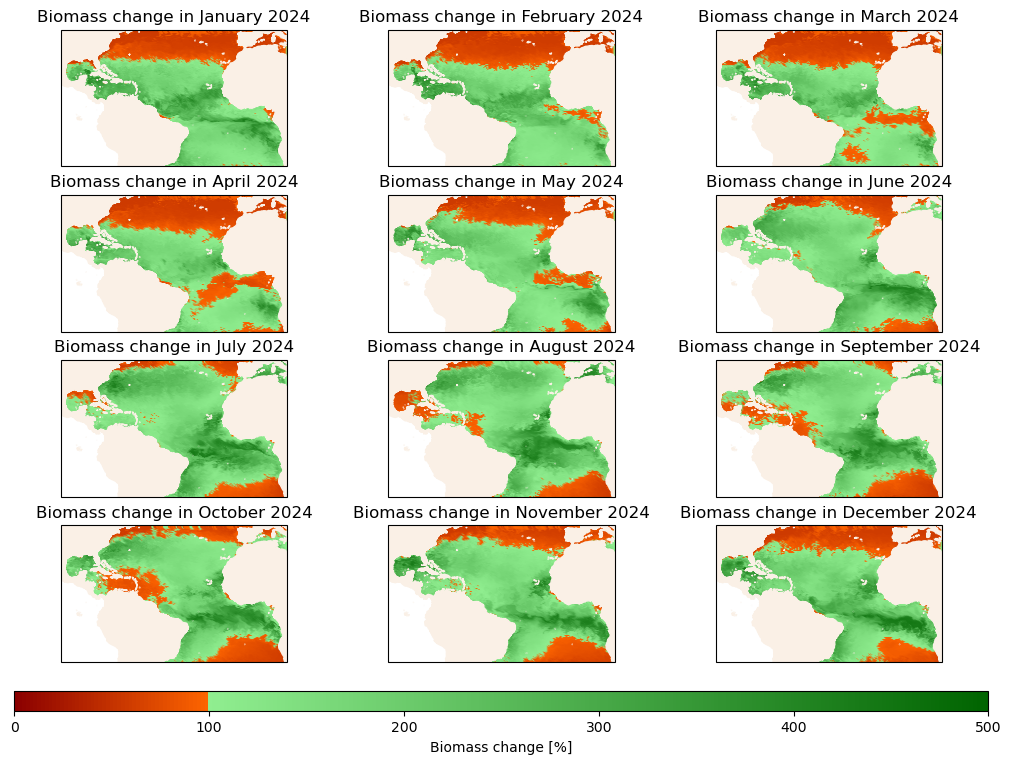

In [2]:
fig, axes = plt.subplots(4, 3, figsize=(10, 7.5), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axes.flatten()):
    df = parcels.read_particlefile(f"../Simulations/Simulation_Basin_2024-{i+1:02d}.parquet")

    to_plot = (
        df.group_by('particle_id')
        .agg([
            pl.col('lon').first().alias('lon'),
            pl.col('lat').first().alias('lat'),
            (pl.col('biomass') * 100).last().alias('biomass')
        ])
        .sort('particle_id')
    )
    cscat = ax.scatter(
        to_plot['lon'],
        to_plot['lat'],
        c=to_plot['biomass'],
        s=10,
        linewidth=0,
        cmap=biomass_change_cmap,
        vmin=0,
        vmax=500,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

    ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2, color='linen')
    ax.set_extent([-100, 16, -25, 45], crs=ccrs.PlateCarree())
    ax.set_title(f"Biomass change in {calendar.month_name[i+1]} 2024")

cbar = fig.colorbar(cscat, ax=axes, orientation='horizontal', pad=0.04, aspect=50, label='Biomass change [%]')

plt.savefig("Figures/Figure6.png", bbox_inches="tight", dpi=300)
plt.show()